# Churn Prediction Model

### Logistic Regression

In [12]:
import pandas as pd
import numpy as np

df_encoded=pd.read_csv("../Data/Telco_Customer_Churn_Features.csv")

In [18]:
print(X_train.select_dtypes(include="object").columns)

Index(['tenure_bucket'], dtype='object')


In [17]:
X_train.select_dtypes(include="object").head()

,tenure_bucket
3738,25-48
3151,13-24
4860,13-24
3867,25-48
3810,0-12


In [19]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["tenure_bucket"],
    drop_first=True
)

In [20]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=["customerID", "Churn"])
y = df_encoded["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8444031103877653


### Random Forest


In [22]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
n_estimators=300, max_depth=8, class_weight="balanced", random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))


              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409

ROC-AUC: 0.8449559533958511


### Feature importances

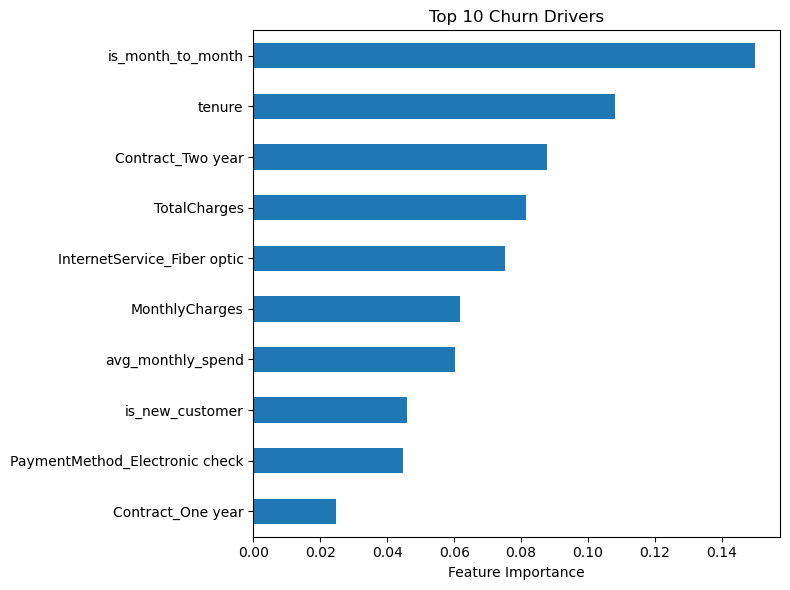

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=X.columns)

importances.sort_values(ascending=False).head(10).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Churn Drivers")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Assign risk score to every customer

In [26]:
df_encoded["churn_probability"] = rf_model.predict_proba(X)[:, 1]
df_encoded["risk_segment"] = pd.cut(
df_encoded["churn_probability"],
bins=[0, 0.3, 0.6, 1.0],
labels=["Low Risk", "Medium Risk", "High Risk"]
)
df_encoded.to_csv("../Data/model_results.csv", index=False)